# RFM Analysis in Python

This notebook implements the steps to perform RFM analysis for customer retention prediction.
We process transaction data, split it into calibration and validation samples, compute RFM metrics, and merge results.

**Objective:** Predict whether a customer makes at least one purchase in period 2 based on period 1 data.

# **1. Data Restructuring**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [4]:
# Load the transaction data
df = pd.read_csv('book_transaction.csv')

df

,ID,BOOKS,DOLLARS,DATE
0,1,1,11.77,1/1/2017
1,2,1,12.00,1/12/2017
2,2,5,77.00,1/12/2017
3,3,2,20.76,1/2/2017
4,3,2,20.76,3/30/2017
...,...,...,...,...
69654,23568,4,83.74,4/5/2017
69655,23568,1,14.99,4/22/2017
69656,23569,2,25.74,3/25/2017
69657,23570,3,51.12,3/25/2017


In [5]:
# Convert the DATE column to datetime format
df['DATE'] = pd.to_datetime(df['DATE'], format='%m/%d/%Y')

# Confirm conversion
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69659 entries, 0 to 69658
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   ID       69659 non-null  int64         
 1   BOOKS    69659 non-null  int64         
 2   DOLLARS  69659 non-null  float64       
 3   DATE     69659 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 2.1 MB
None


## Step 1: Split Data into Calibration and Validation Samples

In [6]:
# Split the data into calibration and validation samples at 9/30/17
calibration_date = pd.Timestamp('2017-09-30')
df_calibration = df[df['DATE'] <= calibration_date]
df_validation = df[df['DATE'] > calibration_date]

print(f'Calibration sample size: {len(df_calibration)}')
print(f'Validation sample size: {len(df_validation)}')

Calibration sample size: 49086
Validation sample size: 20573


## Step 2 and 3: Compute RFM Metrics for Each Sample

In [7]:
# Function to create RFM metrics
def create_rfm(df, end_date):
    rfm = df.groupby('ID').agg(
        monetary=('DOLLARS', 'mean'),
        frequency=('ID', 'count'),
        lastpurchase=('DATE', 'max'),
    ).reset_index()
    rfm['recency'] = (end_date - rfm['lastpurchase']).dt.days
    return rfm

# Generate RFM metrics
calibration_rfm = create_rfm(df_calibration, df_calibration['DATE'].max())
validation_rfm = create_rfm(df_validation, df_validation['DATE'].max())

print(calibration_rfm.head())
print(validation_rfm.head())

   ID   monetary  frequency lastpurchase  recency
0   1  11.770000          1   2017-01-01      272
1   2  44.500000          2   2017-01-12      261
2   3  20.353333          3   2017-04-02      181
3   4  24.673333          3   2017-08-02       59
4   5  32.651250          8   2017-09-15       15
   ID    monetary  frequency lastpurchase  recency
0   3   31.800000          3   2018-05-28       33
1   4   26.480000          1   2017-12-12      200
2   5   41.466667          3   2018-01-03      178
3   7  117.965000          2   2018-03-22      100
4   8   22.967500          4   2018-03-29       93


- The **`groupby`** operation groups the data by `ID` (customer identifier).
- The **`.agg()`** method calculates the following for each customer:
  - **`monetary`**: The average of the `DOLLARS` column, representing the average amount spent per transaction.
  - **`frequency`**: The count of transactions (`ID`), representing how often the customer made a purchase.
  - **`lastpurchase`**: The most recent purchase date (`DATE`).
- **`.reset_index()`** ensures the grouped result is returned as a new DataFrame.
- Subtracting the customer's most recent purchase date (**`lastpurchase`**) from the **`end_date`** calculates the **recency** in days.
- The **`.dt.days`** extracts the number of days from the timedelta result.


## Step 4: Merge Calibration and Validation Data

In [8]:
# Rename all columns except 'ID' to add '_calibration' or '_validation'
calibration_rfm_renamed = calibration_rfm.rename(columns=lambda x: f"{x}_calibration" if x != 'ID' else x)
validation_rfm_renamed = validation_rfm.rename(columns=lambda x: f"{x}_validation" if x != 'ID' else x)

# Check renamed columns
print("Renamed Calibration RFM Columns:", calibration_rfm_renamed.columns.tolist())
print("Renamed Validation RFM Columns:", validation_rfm_renamed.columns.tolist())

# Merge the datasets
merged_data = pd.merge(
    calibration_rfm_renamed,
    validation_rfm_renamed,
    on='ID',
    how='left'
)

# Display the first few rows to confirm the merge
print(merged_data.head())


Renamed Calibration RFM Columns: ['ID', 'monetary_calibration', 'frequency_calibration', 'lastpurchase_calibration', 'recency_calibration']
Renamed Validation RFM Columns: ['ID', 'monetary_validation', 'frequency_validation', 'lastpurchase_validation', 'recency_validation']
   ID  monetary_calibration  frequency_calibration lastpurchase_calibration  \
0   1             11.770000                      1               2017-01-01   
1   2             44.500000                      2               2017-01-12   
2   3             20.353333                      3               2017-04-02   
3   4             24.673333                      3               2017-08-02   
4   5             32.651250                      8               2017-09-15   

   recency_calibration  monetary_validation  frequency_validation  \
0                  272                  NaN                   NaN   
1                  261                  NaN                   NaN   
2                  181            31.800000

#### `how='left'`:
- This specifies a **left join**, meaning:
  - All rows from `calibration_rfm` (the "left" dataframe) will be included in `merged_data`.
  - If a matching `ID` is found in `validation_rfm`, the corresponding values will be added to `merged_data`.
  - If an `ID` exists in `calibration_rfm` but not in `validation_rfm`, the corresponding values from `validation_rfm` will be `NaN` (missing).
- This approach is useful for keeping all customers who made purchases in the calibration period, even if they didn’t make any purchases in the validation period.


## Step 5: Create retained column

In [9]:
# Create a column indicating customer retention in the validation period
merged_data['retained'] = np.where(merged_data['monetary_validation'].notna(), 1, 0)

#### 1. `merged_data['monetary.validation']`
- This column comes from the `validation_rfm` dataframe, which contains the **average monetary value of purchases** in the validation period for each customer.
- If a customer did not make any purchases in the validation period, this column will contain `NaN` for that customer after the left join.

---

#### 2. `.notna()`
- The `notna()` method checks whether each value in the `monetary.validation` column is **not missing** (i.e., not `NaN`).
- It returns a boolean series:
  - `True` for rows where the value in `monetary.validation` is present (indicating the customer made at least one purchase in the validation period).
  - `False` for rows where the value is `NaN` (indicating no purchases in the validation period).

---

#### 3. `np.where(condition, value_if_true, value_if_false)`
- This function from the NumPy library works like an **if-else statement** for arrays or series:
  - If the condition is `True`, it assigns `value_if_true`.
  - If the condition is `False`, it assigns `value_if_false`.

**Here:**
- **Condition**: `merged_data['monetary.validation'].notna()` checks if the customer made a purchase in the validation period.
- **Value if True**: Assign `1` (customer is retained).
- **Value if False**: Assign `0` (customer is not retained).

---

#### 4. Assigning to `merged_data['retained']`
- The result of `np.where` is stored in a new column `retained` in the `merged_data` dataframe.
- For each customer:
  - If they made a purchase in the validation period, `retained` will be `1`.
  - Otherwise, it will be `0`.


In [10]:
# Sort by ID and display the first 10 rows
merged_data = merged_data.sort_values('ID').reset_index(drop=True)
print(merged_data.head(10))

   ID  monetary_calibration  frequency_calibration lastpurchase_calibration  \
0   1             11.770000                      1               2017-01-01   
1   2             44.500000                      2               2017-01-12   
2   3             20.353333                      3               2017-04-02   
3   4             24.673333                      3               2017-08-02   
4   5             32.651250                      8               2017-09-15   
5   6             20.990000                      1               2017-01-01   
6   7             28.740000                      1               2017-01-01   
7   8             26.447500                      4               2017-07-03   
8   9             26.935000                      2               2017-05-13   
9  10             39.310000                      1               2017-01-21   

   recency_calibration  monetary_validation  frequency_validation  \
0                  272                  NaN                  

# **2. Predicting Retention**

## Logistic Regression

In [11]:
# Logistic Regression
logisticfit = smf.logit('retained ~ recency_calibration + frequency_calibration + monetary_calibration', data=merged_data).fit()

# Summary of the logistic regression
print(logisticfit.summary())

Optimization terminated successfully.
         Current function value: 0.493868
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               retained   No. Observations:                23570
Model:                          Logit   Df Residuals:                    23566
Method:                           MLE   Df Model:                            3
Date:                Sun, 30 Mar 2025   Pseudo R-squ.:                  0.1909
Time:                        23:03:07   Log-Likelihood:                -11640.
converged:                       True   LL-Null:                       -14387.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.2037      0.073      2.804      0.005       0.061       0.


#### Logistic Equation:
$
log(Odds) = 0.2037 - 0.0096 \cdot \text{recency_calibration} + 0.2449 \cdot \text{frequency_calibration} + 0.0022 \cdot \text{monetary_calibration}
$

#### Significance of Predictors:
All predictors are statistically significant (**p < 0.05**) and contribute meaningfully to predicting retention.




#### **recency_calibration (-0.0096):**
- **Effect:** A one-unit increase in `recency_calibration` (number of days since the last purchase) **decreases the log-odds** of retention by **0.0096**.

- **Percentage Change in Odds:**
  $
  e^{-0.0096} - 1 \approx -0.95\%
  $
  

#### **frequency_calibration (0.2449):**
- **Effect:** A one-unit increase in `frequency_calibration` **increases the log-odds** of retention by **0.2449**.

- **Percentage Change in Odds:**
  $
  e^{0.2449} - 1 \approx 27.7\%
  $
  

#### **monetary_calibration (0.0022):**
- **Effect:** A one-unit increase in `monetary_calibration` **increases the log-odds** of retention by **0.0022**.

- **Percentage Change in Odds:**
  $
  e^{0.0022} - 1 \approx 0.22\%
  $
  

In [12]:
# Add predictions to the dataset
merged_data['logisticfit'] = logisticfit.predict(merged_data)

In [13]:
merged_data

,ID,monetary_calibration,frequency_calibration,lastpurchase_calibration,recency_calibration,monetary_validation,frequency_validation,lastpurchase_validation,recency_validation,retained,logisticfit
0,1,11.770000,1,2017-01-01,272,NaN,NaN,NaT,NaN,0,0.104521
1,2,44.500000,2,2017-01-12,261,NaN,NaN,NaT,NaN,0,0.151085
2,3,20.353333,3,2017-04-02,181,31.800000,3.0,2018-05-28,33.0,1,0.318122
3,4,24.673333,3,2017-08-02,59,26.480000,1.0,2017-12-12,200.0,1,0.604201
4,5,32.651250,8,2017-09-15,15,41.466667,3.0,2018-01-03,178.0,1,0.889807
...,...,...,...,...,...,...,...,...,...,...,...
23565,23566,36.000000,1,2017-03-25,189,NaN,NaN,NaT,NaN,0,0.214949
23566,23567,20.970000,1,2017-03-25,189,NaN,NaN,NaT,NaN,0,0.209503
23567,23568,40.566667,3,2017-04-22,161,NaN,NaN,NaT,NaN,0,0.371496
23568,23569,25.740000,1,2017-03-25,189,NaN,NaN,NaT,NaN,0,0.211220


#### Confusion Matrix

In [14]:
# start by using 0.5 as a threshold
merged_data['retainedpredict'] = np.where(merged_data['logisticfit'] >= 0.5, 1, 0)

In [15]:
# Confusion Matrix
conf_matrix = confusion_matrix(merged_data['retained'], merged_data['retainedpredict'])
conf_matrix

array([[15051,  1461],
       [ 3746,  3312]])

In [16]:
# Convert to DataFrame for better readability
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)

# Display Confusion Matrix
print("Confusion Matrix:\n", conf_matrix_df)

Confusion Matrix:
           Predicted 0  Predicted 1
Actual 0        15051         1461
Actual 1         3746         3312


## ROC and AUC

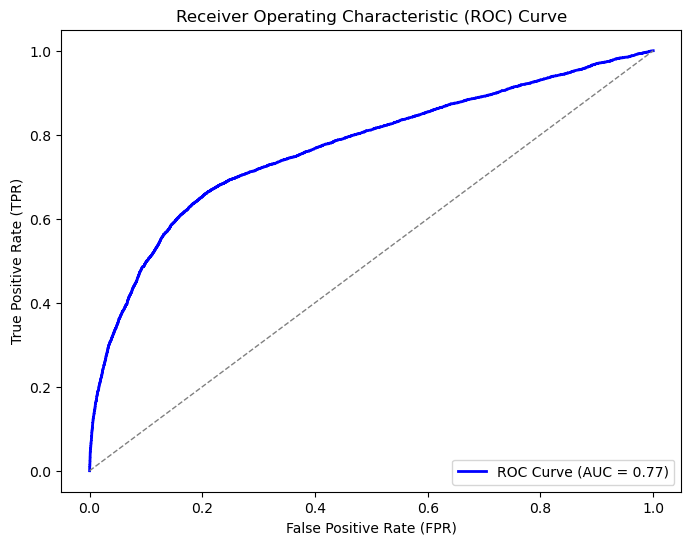

In [17]:
# Logistic Regression Predictions
y_true = merged_data['retained']  # Actual labels
y_score = merged_data['logisticfit']  # Predicted probabilities

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)  # Diagonal line (random model)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# **3. Decile Analysis**

First, take a look at the distribution of these three variables.

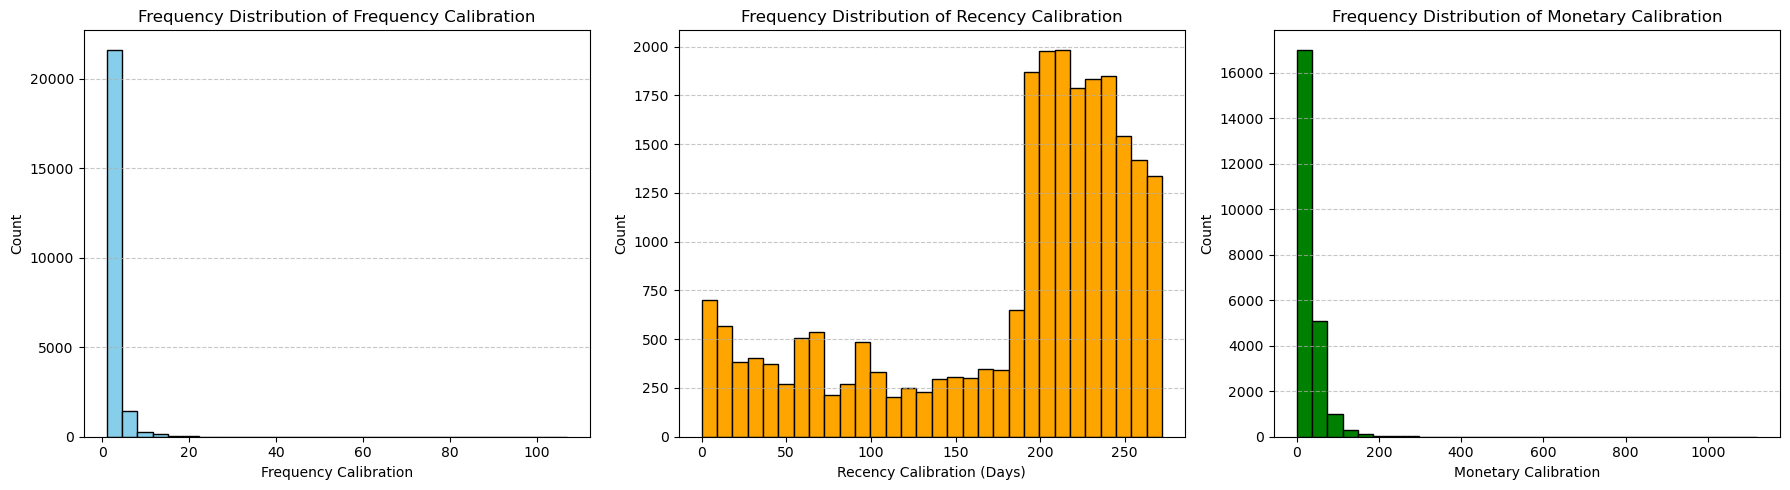

In [18]:
# Plot frequency distributions for all three variables
plt.figure(figsize=(18, 5))

# Frequency Calibration
plt.subplot(1, 3, 1)
plt.hist(merged_data['frequency_calibration'], bins=30, color='skyblue', edgecolor='black')
plt.title('Frequency Distribution of Frequency Calibration')
plt.xlabel('Frequency Calibration')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Recency Calibration
plt.subplot(1, 3, 2)
plt.hist(merged_data['recency_calibration'], bins=30, color='orange', edgecolor='black')
plt.title('Frequency Distribution of Recency Calibration')
plt.xlabel('Recency Calibration (Days)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Monetary Calibration
plt.subplot(1, 3, 3)
plt.hist(merged_data['monetary_calibration'], bins=30, color='green', edgecolor='black')
plt.title('Frequency Distribution of Monetary Calibration')
plt.xlabel('Monetary Calibration')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

*  Recency and Monetary have a wide enough range, allowing them to be divided into deciles.
*  Frequency has a limited range, as most customers appear to make only a few purchases. A closer examination is needed, and dividing it into deciles may not be feasible.

## **Recency and Monetary**

- We typically assign the most desirable customers to the highest quantiles, prioritizing those with high monetary value and recent activity.
- Higher monetary values should be assigned to higher quantiles since they indicate more valuable customers.  
- Higher recency values mean a longer time since the last purchase (i.e., less recent activity), so they should be assigned to lower quantiles.  



In [19]:
# Assign monetary quantiles: Higher monetary values should have higher quantiles
merged_data['monetary_quantile'] = pd.qcut(
    merged_data['monetary_calibration'],
    q=10,
    labels=range(1, 11),  # 1 for lowest monetary, 10 for highest monetary
    duplicates='drop'
)

# Assign recency quantiles: Higher recency values (less recent activity) should have lower quantiles
merged_data['recency_quantile'] = pd.qcut(
    merged_data['recency_calibration'],
    q=10,
    labels=range(10, 0, -1),  # 10 for most recent, 1 for least recent
    duplicates='drop'
)


### Explanation of the Code

The code creates **quantile-based bins** for the variables `monetary_calibration` and `recency_calibration` in the `merged_data` DataFrame.


1. **`pd.qcut`**  
- It sorts the column values in ascending order.
- It divides the sorted values into equal-sized quantiles (e.g., 10 for deciles).
- It assigns labels based on the order of the values.

2. **`duplicates='drop'`**  
   - Ensures duplicate bins are dropped if the data cannot be perfectly divided into the specified number of quantiles (e.g., due to identical values).



#### 1. **`monetary_quantile`**
- Divides the `monetary_calibration` variable into 10 quantiles.
- Each row gets a `monetary_quantile` value ranging from:
  - **1:** Represents the lowest monetary values.
  - **10:** Represents the highest monetary values.

#### 2. **`recency_quantile`**
- Divides the `recency_calibration` variable into 10 quantiles.
- Each row gets a `recency_quantile` value ranging from:
  - **10:** Represents the lowest recency values (most recent purchases).
  - **1:** Represents the highest recency values (least recent purchases).



In [20]:
merged_data

,ID,monetary_calibration,frequency_calibration,lastpurchase_calibration,recency_calibration,monetary_validation,frequency_validation,lastpurchase_validation,recency_validation,retained,logisticfit,retainedpredict,monetary_quantile,recency_quantile
0,1,11.770000,1,2017-01-01,272,NaN,NaN,NaT,NaN,0,0.104521,0,1,1
1,2,44.500000,2,2017-01-12,261,NaN,NaN,NaT,NaN,0,0.151085,0,8,1
2,3,20.353333,3,2017-04-02,181,31.800000,3.0,2018-05-28,33.0,1,0.318122,0,5,7
3,4,24.673333,3,2017-08-02,59,26.480000,1.0,2017-12-12,200.0,1,0.604201,1,6,9
4,5,32.651250,8,2017-09-15,15,41.466667,3.0,2018-01-03,178.0,1,0.889807,1,7,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23565,23566,36.000000,1,2017-03-25,189,NaN,NaN,NaT,NaN,0,0.214949,0,8,7
23566,23567,20.970000,1,2017-03-25,189,NaN,NaN,NaT,NaN,0,0.209503,0,5,7
23567,23568,40.566667,3,2017-04-22,161,NaN,NaN,NaT,NaN,0,0.371496,0,8,8
23568,23569,25.740000,1,2017-03-25,189,NaN,NaN,NaT,NaN,0,0.211220,0,6,7


In [21]:
# Calculate retention percentage, counts, and retained number for monetary quantiles
monetary_quantile_summary = merged_data.groupby('monetary_quantile')['retained'].agg(
    retained_number='sum',
    count='size',
    retention_percentage='mean'
).reset_index()

# Calculate retention percentage, counts, and retained number for recency quantiles
recency_quantile_summary = merged_data.groupby('recency_quantile')['retained'].agg(
    retained_number='sum',
    count='size',
    retention_percentage='mean'
).reset_index()

# Display the summaries
print("Monetary Quantile Summary:")
print(monetary_quantile_summary)

print("\nRecency Quantile Summary:")
print(recency_quantile_summary)

Monetary Quantile Summary:
  monetary_quantile  retained_number  count  retention_percentage
0                 1              387   2357              0.164192
1                 2              564   2357              0.239287
2                 3              470   2407              0.195264
3                 4              704   2307              0.305158
4                 5              855   2357              0.362749
5                 6              753   2364              0.318528
6                 7              787   2352              0.334609
7                 8              820   2357              0.347900
8                 9              896   2356              0.380306
9                10              822   2356              0.348896

Recency Quantile Summary:
  recency_quantile  retained_number  count  retention_percentage
0               10             1801   2394              0.752297
1                9             1454   2377              0.611695
2                8       

/var/folders/g6/ydkvq0nx4tgf9h5rxxfmc63h0000gn/T/ipykernel_2307/3939181165.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monetary_quantile_summary = merged_data.groupby('monetary_quantile')['retained'].agg(
/var/folders/g6/ydkvq0nx4tgf9h5rxxfmc63h0000gn/T/ipykernel_2307/3939181165.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  recency_quantile_summary = merged_data.groupby('recency_quantile')['retained'].agg(


Text(0, 0.5, 'Retention Percentage')

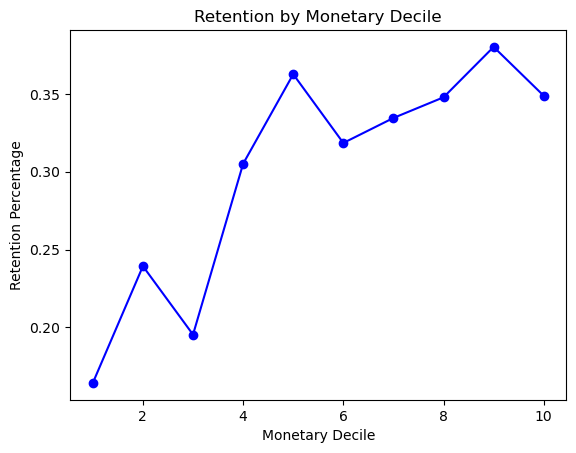

In [22]:
plt.plot(
    monetary_quantile_summary['monetary_quantile'],
    monetary_quantile_summary['retention_percentage'],
    marker='o', linestyle='-', color='blue', label='Monetary Retention'
)
plt.title('Retention by Monetary Decile')
plt.xlabel('Monetary Decile')
plt.ylabel('Retention Percentage')

Text(0, 0.5, 'Retention Percentage')

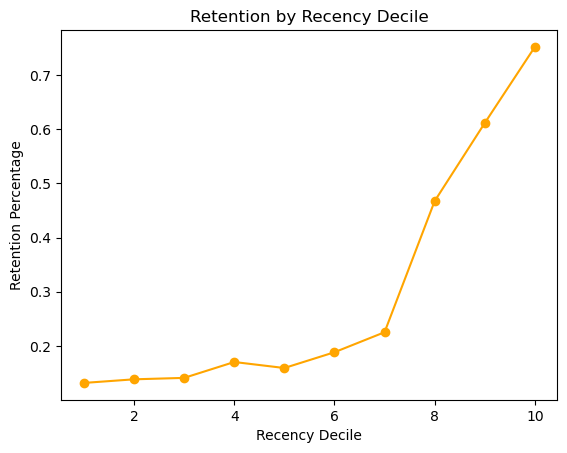

In [23]:
plt.plot(
    recency_quantile_summary['recency_quantile'],
    recency_quantile_summary['retention_percentage'],
    marker='o', linestyle='-', color='orange', label='Recency Retention'
)
plt.title('Retention by Recency Decile')
plt.xlabel('Recency Decile')
plt.ylabel('Retention Percentage')

## **Frequncy**

First, we examine the range and distribution of Frequency to determine its variability. If dividing it into deciles is not feasible, we will explore alternative methods.

In [24]:
# Create a frequency table for 'frequency_calibration'
frequency_table = merged_data['frequency_calibration'].value_counts().reset_index()
frequency_table.columns = ['Frequency Calibration', 'Count']
frequency_table = frequency_table.sort_values(by='Frequency Calibration')

# Calculate the cumulative distribution
frequency_table['Cumulative Count'] = frequency_table['Count'].cumsum()
frequency_table['Cumulative Distribution'] = (frequency_table['Cumulative Count'] / frequency_table['Count'].sum()) * 100

# Display the updated frequency table
print(frequency_table)


    Frequency Calibration  Count  Cumulative Count  Cumulative Distribution
0                       1  13954             13954                59.202376
1                       2   4495             18449                78.273229
2                       3   2090             20539                87.140433
3                       4   1083             21622                91.735257
4                       5    620             22242                94.365719
5                       6    359             22601                95.888842
6                       7    259             22860                96.987696
7                       8    212             23072                97.887145
8                       9    131             23203                98.442936
9                      10     75             23278                98.761137
10                     11     62             23340                99.024183
11                     12     50             23390                99.236317
13          

### Analysis of Frequency Calibration

Given the highly skewed distribution of the `frequency_calibration` variable (with 60% of the customers having a frequency of 1), standard decile analysis might not provide meaningful insights. Instead, a **custom binning approach** or **percentile-based grouping** can be more appropriate to capture meaningful patterns in retention.

---

### **Steps for Analysis**

#### 1. **Custom Grouping for Frequency Calibration**
Instead of using deciles, group the data into meaningful bins based on frequency values:
- **Bin 1**: Frequency = 1 (single purchase)
- **Bin 2**: Frequency = 2–3 (low-frequency repeat purchases)
- **Bin 3**: Frequency = 4–5 (medium-frequency repeat purchases)
- **Bin 4**: Frequency = 6–10 (high-frequency repeat purchases)
- **Bin 5**: Frequency > 10 (very high-frequency repeat purchases)

---

#### 2. **Calculate Retention for Each Group**
For each custom frequency group, calculate:
- **Retention Percentage**: The proportion of customers retained in each group.
- **Number of Customers (`n`)**: The count of customers in each group.

---

#### 3. **Visualize the Retention**
- **Plot the retention percentage** for each frequency group.
- Optionally, include a **cumulative retention chart** if needed.



In [25]:
# Custom frequency bins
bins = [0, 1, 3, 5, 10, merged_data['frequency_calibration'].max()]
labels = ['1', '2', '3', '4', '5']
merged_data['frequency_group'] = pd.cut(merged_data['frequency_calibration'], bins=bins, labels=labels, right=True)


In [26]:
# Calculate retention percentage, counts, and retained number for each frequency group
frequency_summary = merged_data.groupby('frequency_group')['retained'].agg(
    retained_number='sum',      # Total number of retained customers (binary 0/1)
    count='size',               # Total number of customers in each frequency group
    retention_percentage='mean' # Mean of 'retained' gives retention rate
).reset_index()


/var/folders/g6/ydkvq0nx4tgf9h5rxxfmc63h0000gn/T/ipykernel_2307/3418884308.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frequency_summary = merged_data.groupby('frequency_group')['retained'].agg(


In [27]:
frequency_summary

,frequency_group,retained_number,count,retention_percentage
0,1,2046,13954,0.146625
1,2,2793,6585,0.424146
2,3,1114,1703,0.654140
3,4,834,1036,0.805019
4,5,271,292,0.928082


Text(0, 0.5, 'Retention Percentage')

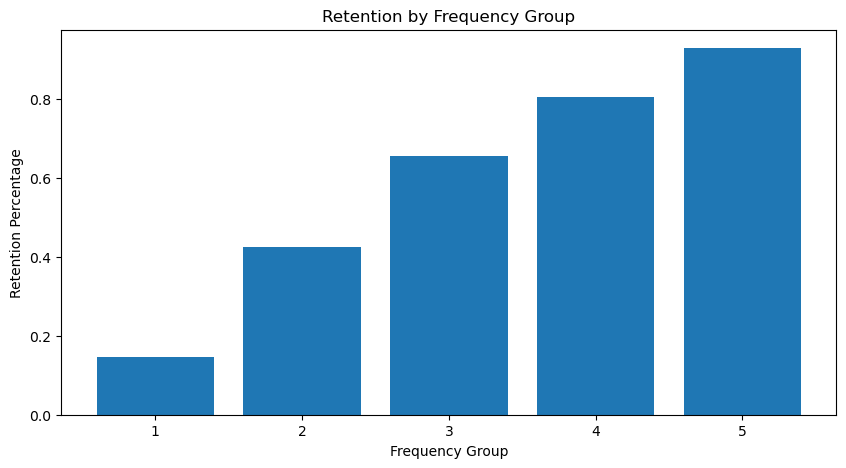

In [28]:
# Plot retention percentage by frequency group
plt.figure(figsize=(10, 5))
plt.bar(frequency_summary['frequency_group'], frequency_summary['retention_percentage'])
plt.title('Retention by Frequency Group')
plt.xlabel('Frequency Group')
plt.ylabel('Retention Percentage')



#### **Retention Trends**:
- Retention correlates positively with purchase frequency.
- Single-purchase customers are the most challenging group to retain.

#### **Customer Distribution**:
- The bulk of the customer base falls in the single-purchase group, highlighting a need for strategies to drive repeat purchases.

#### **Strategic Implications**:
1. **Focus on Retaining Single-Purchase Customers**:
   - Develop re-engagement campaigns targeting customers with a frequency of 1.

2. **Nurture High-Frequency Customers**:
   - Maintain loyalty through rewards programs or personalized offers for customers in the **6–10** and **>10** frequency groups.


# **4. Selectivity Analysis**

## Monetary

In [29]:
monetary_quantile_summary

,monetary_quantile,retained_number,count,retention_percentage
0,1,387,2357,0.164192
1,2,564,2357,0.239287
2,3,470,2407,0.195264
3,4,704,2307,0.305158
4,5,855,2357,0.362749
5,6,753,2364,0.318528
6,7,787,2352,0.334609
7,8,820,2357,0.347900
8,9,896,2356,0.380306
9,10,822,2356,0.348896


In [30]:
# Sorting in descending order based on monetary_quantile
monetary_quantile_summary = monetary_quantile_summary.sort_values(
    by="monetary_quantile", ascending=False
).reset_index(drop=True)


In [31]:
monetary_quantile_summary

,monetary_quantile,retained_number,count,retention_percentage
0,10,822,2356,0.348896
1,9,896,2356,0.380306
2,8,820,2357,0.347900
3,7,787,2352,0.334609
4,6,753,2364,0.318528
5,5,855,2357,0.362749
6,4,704,2307,0.305158
7,3,470,2407,0.195264
8,2,564,2357,0.239287
9,1,387,2357,0.164192


In [32]:
# Calculate total retained customers across all quantiles
total_retained = monetary_quantile_summary["retained_number"].sum()

# Calculate overall retained rate (total retained customers / total customers)
total_customers = monetary_quantile_summary["count"].sum()
overall_retained_rate = total_retained / total_customers

# Display results
print(f"Total Retained Customers: {total_retained}")
print(f"Overall Retained Rate: {overall_retained_rate:.4f}")


Total Retained Customers: 7058
Overall Retained Rate: 0.2994


In [33]:
# Create cumulative metrics for lift and gain
monetary_quantile_summary['cumulative_customers'] = monetary_quantile_summary['count'].cumsum()

# Compute cumulative retained customers
monetary_quantile_summary['cumulative_retained'] = (monetary_quantile_summary['retained_number']).cumsum()

# Compute cumulative retained rate
monetary_quantile_summary['cumulative_retained_rate'] = (
    monetary_quantile_summary['cumulative_retained'] / monetary_quantile_summary['cumulative_customers']
)

# Compute cumulative percentage of customers
monetary_quantile_summary['cumulative_pct_customers'] = (
    monetary_quantile_summary['cumulative_customers'] / total_customers
)

# Compute cumulative lift
monetary_quantile_summary['cumulative_lift'] = monetary_quantile_summary['cumulative_retained_rate'] / overall_retained_rate

# Compute cumulative gain
monetary_quantile_summary['cumulative_gain'] = monetary_quantile_summary['cumulative_retained'] / total_retained



In [34]:
monetary_quantile_summary


,monetary_quantile,retained_number,count,retention_percentage,cumulative_customers,cumulative_retained,cumulative_retained_rate,cumulative_pct_customers,cumulative_lift,cumulative_gain
0,10,822,2356,0.348896,2356,822,0.348896,0.099958,1.165130,0.116464
1,9,896,2356,0.380306,4712,1718,0.364601,0.199915,1.217575,0.243412
2,8,820,2357,0.347900,7069,2538,0.359032,0.299915,1.198979,0.359592
3,7,787,2352,0.334609,9421,3325,0.352935,0.399703,1.178617,0.471097
4,6,753,2364,0.318528,11785,4078,0.346033,0.500000,1.155568,0.577784
5,5,855,2357,0.362749,14142,4933,0.348819,0.600000,1.164872,0.698923
6,4,704,2307,0.305158,16449,5637,0.342696,0.697879,1.144423,0.798668
7,3,470,2407,0.195264,18856,6107,0.323876,0.800000,1.081574,0.865259
8,2,564,2357,0.239287,21213,6671,0.314477,0.900000,1.050187,0.945169
9,1,387,2357,0.164192,23570,7058,0.299448,1.000000,1.000000,1.000000


## Recency

In [35]:
recency_quantile_summary

,recency_quantile,retained_number,count,retention_percentage
0,10,1801,2394,0.752297
1,9,1454,2377,0.611695
2,8,1076,2302,0.467420
3,7,580,2576,0.225155
4,6,408,2168,0.188192
5,5,382,2402,0.159034
6,4,393,2310,0.170130
7,3,331,2351,0.140791
8,2,339,2454,0.138142
9,1,294,2236,0.131485


In [36]:
# Create cumulative metrics for lift and gain for recency quantiles
recency_quantile_summary['cumulative_customers'] = recency_quantile_summary['count'].cumsum()

# Compute cumulative retained customers
recency_quantile_summary['cumulative_retained'] = recency_quantile_summary['retained_number'].cumsum()

# Compute cumulative retained rate
recency_quantile_summary['cumulative_retained_rate'] = (
    recency_quantile_summary['cumulative_retained'] / recency_quantile_summary['cumulative_customers']
)

# Compute cumulative percentage of customers
recency_quantile_summary['cumulative_pct_customers'] = (
    recency_quantile_summary['cumulative_customers'] / total_customers
)

# Compute cumulative lift
recency_quantile_summary['cumulative_lift'] = recency_quantile_summary['cumulative_retained_rate'] / overall_retained_rate

# Compute cumulative gain
recency_quantile_summary['cumulative_gain'] = recency_quantile_summary['cumulative_retained'] / total_retained
recency_quantile_summary

,recency_quantile,retained_number,count,retention_percentage,cumulative_customers,cumulative_retained,cumulative_retained_rate,cumulative_pct_customers,cumulative_lift,cumulative_gain
0,10,1801,2394,0.752297,2394,1801,0.752297,0.101570,2.512277,0.255171
1,9,1454,2377,0.611695,4771,3255,0.682247,0.202418,2.278345,0.461179
2,8,1076,2302,0.467420,7073,4331,0.612329,0.300085,2.044855,0.613630
3,7,580,2576,0.225155,9649,4911,0.508965,0.409376,1.699674,0.695806
4,6,408,2168,0.188192,11817,5319,0.450114,0.501358,1.503144,0.753613
5,5,382,2402,0.159034,14219,5701,0.400942,0.603267,1.338936,0.807736
6,4,393,2310,0.170130,16529,6094,0.368685,0.701273,1.231215,0.863417
7,3,331,2351,0.140791,18880,6425,0.340307,0.801018,1.136447,0.910315
8,2,339,2454,0.138142,21334,6764,0.317053,0.905134,1.058789,0.958345
9,1,294,2236,0.131485,23570,7058,0.299448,1.000000,1.000000,1.000000


## Frequency

In [37]:
frequency_summary

,frequency_group,retained_number,count,retention_percentage
0,1,2046,13954,0.146625
1,2,2793,6585,0.424146
2,3,1114,1703,0.654140
3,4,834,1036,0.805019
4,5,271,292,0.928082


In [38]:
frequency_summary.sort_values(by='frequency_group', ascending=False, inplace=True)
frequency_summary

,frequency_group,retained_number,count,retention_percentage
4,5,271,292,0.928082
3,4,834,1036,0.805019
2,3,1114,1703,0.654140
1,2,2793,6585,0.424146
0,1,2046,13954,0.146625


In [39]:

# Create cumulative metrics for lift and gain for frequency groups
frequency_summary['cumulative_customers'] = frequency_summary['count'].cumsum()

# Compute cumulative retained customers
frequency_summary['cumulative_retained'] = frequency_summary['retained_number'].cumsum()

# Compute cumulative retained rate
frequency_summary['cumulative_retained_rate'] = (
    frequency_summary['cumulative_retained'] / frequency_summary['cumulative_customers']
)


# Compute cumulative percentage of customers
frequency_summary['cumulative_pct_customers'] = (
    frequency_summary['cumulative_customers'] / total_customers
)
# Compute cumulative lift
frequency_summary['cumulative_lift'] = frequency_summary['cumulative_retained_rate'] / overall_retained_rate

# Compute cumulative gain
frequency_summary['cumulative_gain'] = frequency_summary['cumulative_retained'] / total_retained

frequency_summary

,frequency_group,retained_number,count,retention_percentage,cumulative_customers,cumulative_retained,cumulative_retained_rate,cumulative_pct_customers,cumulative_lift,cumulative_gain
4,5,271,292,0.928082,292,271,0.928082,0.012389,3.099305,0.038396
3,4,834,1036,0.805019,1328,1105,0.832078,0.056343,2.778703,0.156560
2,3,1114,1703,0.654140,3031,2219,0.732102,0.128596,2.444834,0.314395
1,2,2793,6585,0.424146,9616,5012,0.521215,0.407976,1.740582,0.710116
0,1,2046,13954,0.146625,23570,7058,0.299448,1.000000,1.000000,1.000000


## a. Cumulative Lift Chart

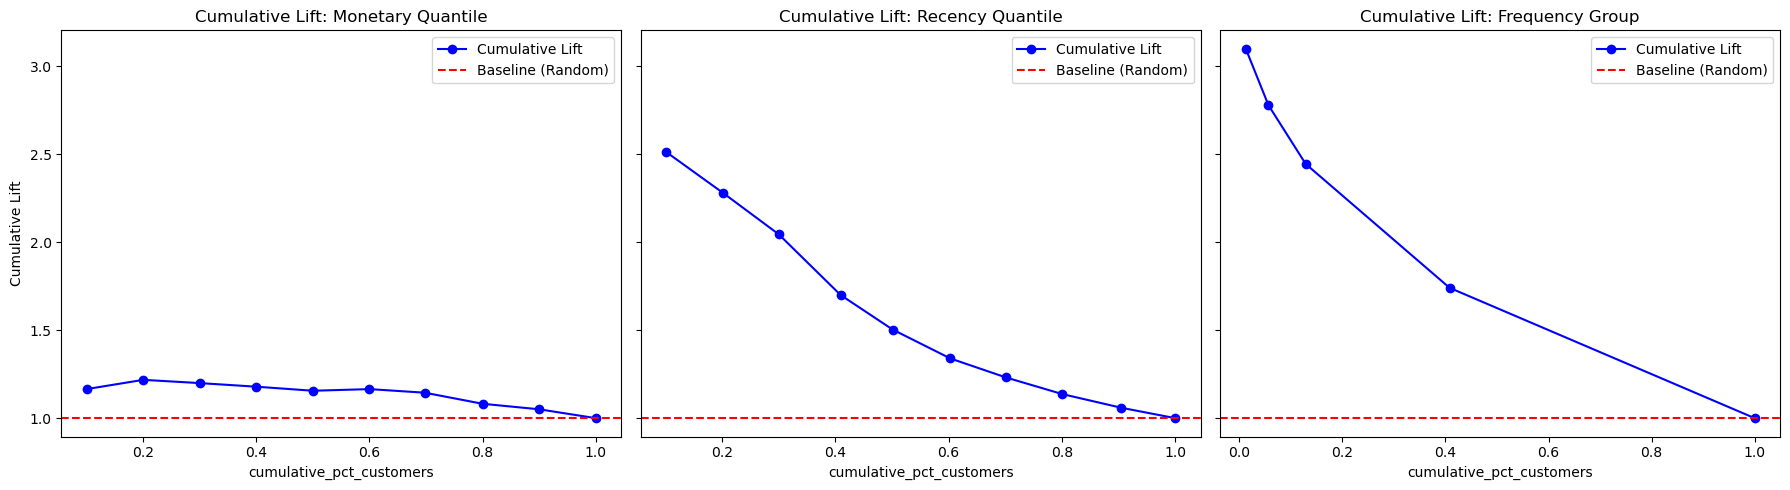

In [40]:

# Create a 1-row layout for cumulative lift charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Define a common color for all charts
plot_color = 'blue'

# Cumulative Lift Chart for Monetary Quantile
axes[0].plot(monetary_quantile_summary['cumulative_pct_customers'],
             monetary_quantile_summary['cumulative_lift'],
             marker='o', linestyle='-', color=plot_color, label="Cumulative Lift")

axes[0].axhline(y=1, color='red', linestyle='--', label="Baseline (Random)")  # Baseline
axes[0].set_title('Cumulative Lift: Monetary Quantile')
axes[0].set_xlabel('cumulative_pct_customers')
axes[0].set_ylabel('Cumulative Lift')
axes[0].legend()


# Cumulative Lift Chart for Recency Quantile
axes[1].plot(recency_quantile_summary['cumulative_pct_customers'],
             recency_quantile_summary['cumulative_lift'],
             marker='o', linestyle='-', color=plot_color, label="Cumulative Lift")

axes[1].axhline(y=1, color='red', linestyle='--', label="Baseline (Random)")
axes[1].set_title('Cumulative Lift: Recency Quantile')
axes[1].set_xlabel('cumulative_pct_customers')
axes[1].legend()


# Cumulative Lift Chart for Frequency Group
axes[2].plot(frequency_summary['cumulative_pct_customers'],
             frequency_summary['cumulative_lift'],
             marker='o', linestyle='-', color=plot_color, label="Cumulative Lift")

axes[2].axhline(y=1, color='red', linestyle='--', label="Baseline (Random)")
axes[2].set_title('Cumulative Lift: Frequency Group')
axes[2].set_xlabel('cumulative_pct_customers')
axes[2].legend()


# Adjust layout for readability
plt.tight_layout()
plt.show()


## b. Gain Chart

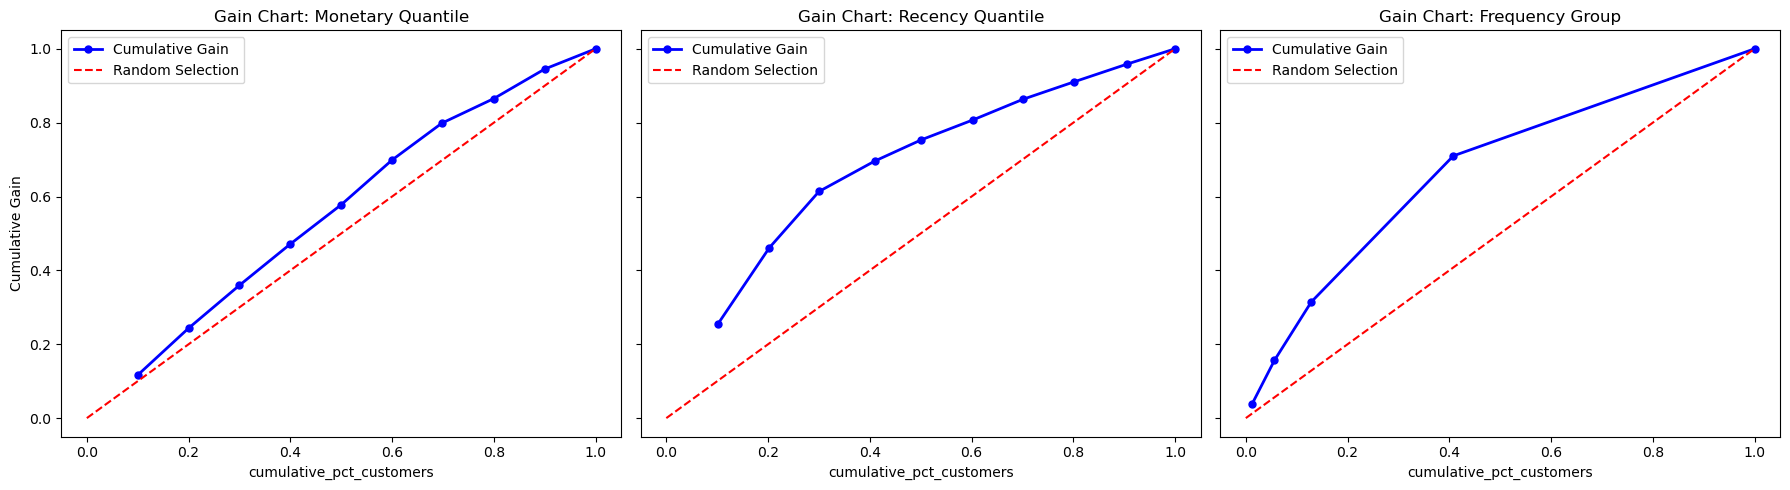

In [41]:
# Create a 1-row layout for cumulative gain charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Gain Chart for Monetary Quantile
axes[0].plot(monetary_quantile_summary['cumulative_pct_customers'],
             monetary_quantile_summary['cumulative_gain'],
             marker='o', linestyle='-', linewidth=2, markersize=5, color=plot_color, label="Cumulative Gain")
# Add the 45-degree line representing random selection
axes[0].plot([0, 1], [0, 1], 'r--', label="Random Selection")
axes[0].set_title('Gain Chart: Monetary Quantile')
axes[0].set_xlabel('cumulative_pct_customers')
axes[0].set_ylabel('Cumulative Gain')
axes[0].legend()

# Gain Chart for Recency Quantile
axes[1].plot(recency_quantile_summary['cumulative_pct_customers'],
             recency_quantile_summary['cumulative_gain'],
             marker='o', linestyle='-', linewidth=2, markersize=5, color=plot_color, label="Cumulative Gain")

# Add the 45-degree line representing random selection
axes[1].plot([0, 1], [0, 1], 'r--', label="Random Selection")

axes[1].set_title('Gain Chart: Recency Quantile')
axes[1].set_xlabel('cumulative_pct_customers')
axes[1].legend()

# Gain Chart for Frequency Group
axes[2].plot(frequency_summary['cumulative_pct_customers'],
             frequency_summary['cumulative_gain'],
             marker='o', linestyle='-', linewidth=2, markersize=5, color=plot_color, label="Cumulative Gain")

# Add the 45-degree line representing random selection
axes[2].plot([0, 1], [0, 1], 'r--', label="Random Selection")

axes[2].set_title('Gain Chart: Frequency Group')
axes[2].set_xlabel('cumulative_pct_customers')
axes[2].legend()

# Adjust layout for readability
plt.tight_layout()
plt.show()
